# Passport Page Identification with a CNN (TensorFlow)

This notebook trains a **binary image classifier** that predicts whether a document page contains a passport:

- `0` — no passport
- `1` — passport page

The workflow is based on Eran Feit's [Butterfly Species Identification CNN tutorial](https://eranfeit.net/butterfly-species-identification-cnn-with-tensorflow-python/): CSV exploration, image preview, augmentation, a custom Sequential CNN, callbacks, training curves, and evaluation on unseen images.

Important adaptations for this dataset:

1. The output uses one sigmoid neuron and binary cross-entropy.
2. Pages from the same source document are kept in the same split to prevent leakage.
3. Class weights compensate for the smaller passport class.
4. Augmentation does not mirror pages because mirrored text is not a realistic document page.
5. Evaluation includes precision, recall, F1, ROC-AUC, and a confusion matrix—not accuracy alone.


## 1. Environment

Run the installation line only if the packages are missing. A GPU is recommended but not required.


In [1]:
# Uncomment and run once if needed:
%pip install -q tensorflow pandas numpy matplotlib seaborn scikit-learn pillow


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from sklearn.model_selection import GroupShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow: 2.21.0
GPU devices: []


## 2. Configuration

Place the notebook and `passport_page_labels_big_dataset.csv` in the project root. The CSV paths are interpreted relative to `IMAGE_ROOT`. Change only these path variables if your files are stored elsewhere.


In [3]:
PROJECT_DIR = Path(".").resolve()
CSV_FILE = PROJECT_DIR / "passport_page_labels_big_dataset.csv"
IMAGE_ROOT = PROJECT_DIR
ARTIFACT_DIR = PROJECT_DIR / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 40
DECISION_THRESHOLD = 0.50

BEST_MODEL_PATH = ARTIFACT_DIR / "best_passport_page_cnn.keras"

print("CSV:", CSV_FILE)
print("Image root:", IMAGE_ROOT)


CSV: C:\Users\user\PycharmProjects\Project.DS\passport_page_labels_big_dataset.csv
Image root: C:\Users\user\PycharmProjects\Project.DS


## 3. Load and inspect the labels

In [5]:
df = pd.read_csv(CSV_FILE, encoding="utf-8-sig")

required_columns = {"image_path", "label"}
missing_columns = required_columns - set(df.columns)
if missing_columns:
    raise ValueError(f"Missing required CSV columns: {sorted(missing_columns)}")

df = df[["image_path", "label"]].dropna().copy()
df["label"] = df["label"].astype(int)

if not set(df["label"].unique()).issubset({0, 1}):
    raise ValueError("The label column must contain only 0 and 1.")


def resolve_image_path(raw_path):
    # The supplied CSV uses Windows backslashes; converting them also works on Linux/macOS.
    normalized = Path(str(raw_path).replace("\\", "/"))
    return str(normalized if normalized.is_absolute() else IMAGE_ROOT / normalized)


def document_id_from_path(raw_path):
    # Example: passport_normal_00000_p02.jpg -> passport_normal_00000
    stem = Path(str(raw_path).replace("\\", "/")).stem
    return re.sub(r"_p\d+$", "", stem, flags=re.IGNORECASE)


df["resolved_path"] = df["image_path"].map(resolve_image_path)
df["document_id"] = df["image_path"].map(document_id_from_path)

missing_files = ~df["resolved_path"].map(lambda path: Path(path).exists())
if missing_files.any():
    display(df.loc[missing_files, ["image_path", "resolved_path"]].head(10))
    raise FileNotFoundError(
        f"{missing_files.sum()} image files were not found. "
        "Set IMAGE_ROOT to the directory relative to which the CSV paths are valid."
    )

print(f"Pages: {len(df):,}")
print(f"Source documents: {df['document_id'].nunique():,}")
display(df.head())


Pages: 839
Source documents: 322


,image_path,label,resolved_path,document_id
0,data\pages\passport_normal\passport_normal_000...,1,C:\Users\user\PycharmProjects\Project.DS\data\...,passport_normal_00000
1,data\pages\filler_text\passport_normal_00000_p...,0,C:\Users\user\PycharmProjects\Project.DS\data\...,passport_normal_00000
2,data\pages\passport_edge\passport_edge_00001_p...,1,C:\Users\user\PycharmProjects\Project.DS\data\...,passport_edge_00001
3,data\pages\filler_text\passport_edge_00001_p02...,0,C:\Users\user\PycharmProjects\Project.DS\data\...,passport_edge_00001
4,data\pages\filler_text\passport_normal_00002_p...,0,C:\Users\user\PycharmProjects\Project.DS\data\...,passport_normal_00002


,label,class,pages,percentage
0,0,No passport,595,70.917759
1,1,Passport,244,29.082241


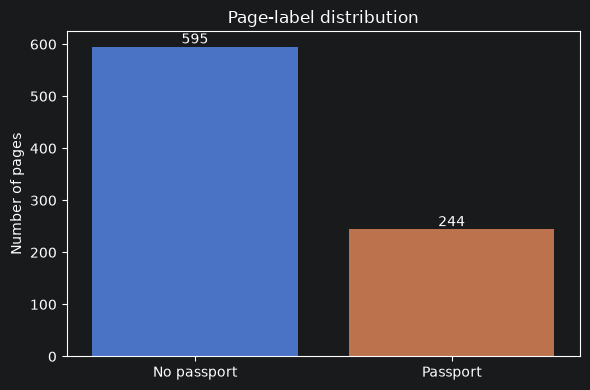

In [6]:
LABEL_NAMES = {0: "No passport", 1: "Passport"}

class_summary = (
    df["label"]
    .value_counts()
    .sort_index()
    .rename_axis("label")
    .reset_index(name="pages")
)
class_summary["class"] = class_summary["label"].map(LABEL_NAMES)
class_summary["percentage"] = 100 * class_summary["pages"] / len(df)
display(class_summary[["label", "class", "pages", "percentage"]])

plt.figure(figsize=(6, 4))
ax = sns.barplot(data=class_summary, x="class", y="pages", hue="class", legend=False)
ax.set_title("Page-label distribution")
ax.set_xlabel("")
ax.set_ylabel("Number of pages")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


## 4. Preview random pages

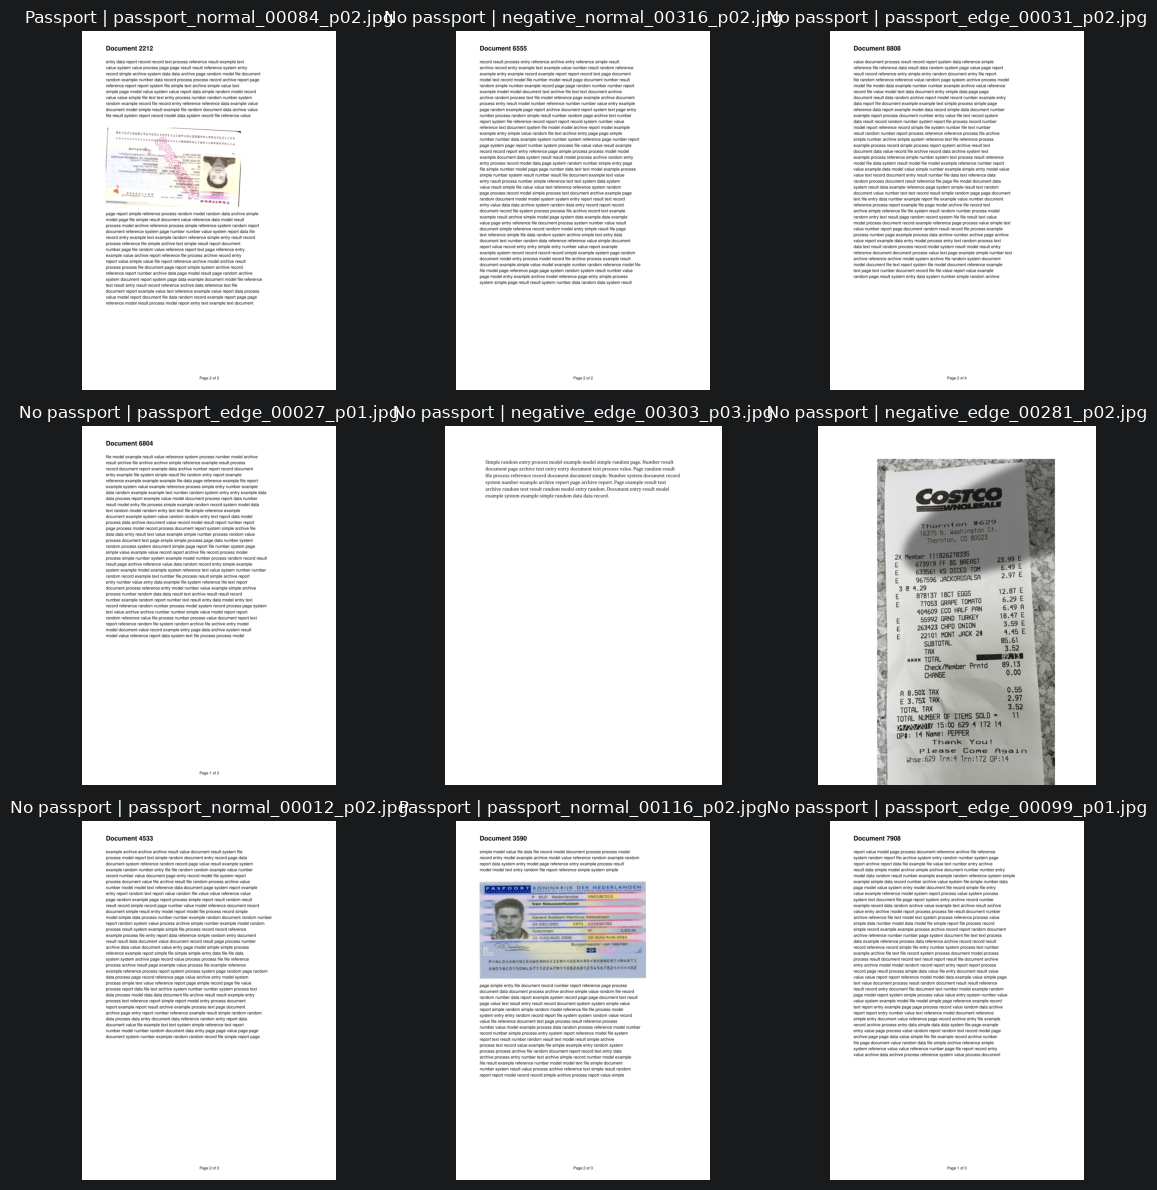

In [7]:
sample_count = min(9, len(df))
sample_pages = df.sample(sample_count, random_state=SEED)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = np.asarray(axes).reshape(-1)

for ax in axes:
    ax.axis("off")

for ax, (_, row) in zip(axes, sample_pages.iterrows()):
    with Image.open(row["resolved_path"]) as image:
        ax.imshow(image.convert("RGB"))
    ax.set_title(f"{LABEL_NAMES[row['label']]} | {Path(row['resolved_path']).name}")
    ax.axis("off")

plt.tight_layout()
plt.show()


## 5. Document-aware train/validation/test split

A random page-level split can put one page from a document in training and another page from the same document in validation or test. With generated documents, this may produce misleadingly high scores. `GroupShuffleSplit` keeps all pages with the same `document_id` together.

The target proportions are approximately 70% training, 15% validation, and 15% test.


In [8]:
outer_split = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_index, temporary_index = next(
    outer_split.split(df, y=df["label"], groups=df["document_id"])
)

train_df = df.iloc[train_index].reset_index(drop=True)
temporary_df = df.iloc[temporary_index].reset_index(drop=True)

inner_split = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
validation_index, test_index = next(
    inner_split.split(
        temporary_df,
        y=temporary_df["label"],
        groups=temporary_df["document_id"],
    )
)

validation_df = temporary_df.iloc[validation_index].reset_index(drop=True)
test_df = temporary_df.iloc[test_index].reset_index(drop=True)

# Verify that no source document appears in more than one split.
train_groups = set(train_df["document_id"])
validation_groups = set(validation_df["document_id"])
test_groups = set(test_df["document_id"])

assert train_groups.isdisjoint(validation_groups)
assert train_groups.isdisjoint(test_groups)
assert validation_groups.isdisjoint(test_groups)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "pages": [len(train_df), len(validation_df), len(test_df)],
        "documents": [
            train_df["document_id"].nunique(),
            validation_df["document_id"].nunique(),
            test_df["document_id"].nunique(),
        ],
        "passport_pages": [
            int(train_df["label"].sum()),
            int(validation_df["label"].sum()),
            int(test_df["label"].sum()),
        ],
        "passport_rate": [
            train_df["label"].mean(),
            validation_df["label"].mean(),
            test_df["label"].mean(),
        ],
    }
)

display(split_summary.style.format({"passport_rate": "{:.1%}"}))


,split,pages,documents,passport_pages,passport_rate
0,train,590,225,173,29.3%
1,validation,126,48,37,29.4%
2,test,123,49,34,27.6%


## 6. TensorFlow input pipeline

In [9]:
AUTOTUNE = tf.data.AUTOTUNE


def load_page(path, label):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image = tf.ensure_shape(image, [None, None, 3])
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    return image, tf.cast(label, tf.float32)


def make_dataset(frame, training=False):
    dataset = tf.data.Dataset.from_tensor_slices(
        (frame["resolved_path"].to_numpy(), frame["label"].to_numpy())
    )

    if training:
        dataset = dataset.shuffle(
            buffer_size=len(frame),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    return (
        dataset
        .map(load_page, num_parallel_calls=AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(AUTOTUNE)
    )


train_ds = make_dataset(train_df, training=True)
validation_ds = make_dataset(validation_df)
test_ds = make_dataset(test_df)

image_batch, label_batch = next(iter(train_ds))
print("Image batch:", image_batch.shape)
print("Label batch:", label_batch.shape)


Image batch: (16, 224, 224, 3)
Label batch: (16,)


## 7. Class weights and data augmentation

Class weights make an error on the smaller passport class count more during training. Augmentation is active only during training. Rotation, translation, zoom, and contrast variation help with photographed or rotated pages; horizontal flipping is intentionally excluded.


In [10]:
classes = np.array([0, 1])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].to_numpy(),
)
CLASS_WEIGHTS = {int(label): float(weight) for label, weight in zip(classes, weights)}
print("Class weights:", CLASS_WEIGHTS)

data_augmentation = models.Sequential(
    [
        layers.RandomRotation(0.10, fill_mode="reflect"),
        layers.RandomTranslation(0.08, 0.08, fill_mode="reflect"),
        layers.RandomZoom(0.12, 0.12, fill_mode="reflect"),
        layers.RandomContrast(0.15),
    ],
    name="document_augmentation",
)


Class weights: {0: 0.7074340527577938, 1: 1.7052023121387283}


## 8. Build the custom CNN

Early convolutional layers learn edges and simple visual structures. Deeper layers learn higher-level patterns such as the passport photograph region, document layout, and MRZ-like structure. Global average pooling keeps the parameter count lower than a large `Flatten` layer.


In [11]:
model = models.Sequential(
    [
        layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
        layers.Rescaling(1.0 / 255),
        data_augmentation,

        layers.Conv2D(32, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(64, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(128, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.Conv2D(256, 3, padding="same", use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),

        layers.GlobalAveragePooling2D(),
        layers.Dropout(0.40),
        layers.Dense(
            128,
            activation="relu",
            kernel_regularizer=regularizers.l2(1e-4),
        ),
        layers.Dropout(0.30),
        layers.Dense(1, activation="sigmoid"),
    ],
    name="passport_page_cnn",
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="roc_auc"),
    ],
)

model.summary()


Model: "passport_page_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ document_augmentation           │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             

 Total params: 422,881 (1.61 MB)

 Trainable params: 421,921 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

## 9. Train with early stopping and checkpointing

In [12]:
callbacks = [
    ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1,
    ),
    EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=6,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks,
)


Epoch 1/40


C:\Users\user\PycharmProjects\Project.DS\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6797 - loss: 0.6495 - precision: 0.4677 - recall: 0.6705 - roc_auc: 0.7176           
Epoch 1: val_loss improved from None to 0.62431, saving model to C:\Users\user\PycharmProjects\Project.DS\artifacts\best_passport_page_cnn.keras

Epoch 1: finished saving model to C:\Users\user\PycharmProjects\Project.DS\artifacts\best_passport_page_cnn.keras
37/37 ━━━━━━━━━━━━━━━━━━━━ 115s 3s/step - accuracy: 0.6797 - loss: 0.6495 - precision: 0.4677 - recall: 0.6705 - roc_auc: 0.7176 - val_accuracy: 0.7063 - val_loss: 0.6243 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - val_roc_auc: 0.4677 - learning_rate: 0.0010
Epoch 2/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8390 - loss: 0.4479 - precision: 0.6893 - recall: 0.8208 - roc_auc: 0.8933  
Epoch 2: val_loss did not improve from 0.62431
37/37 ━━━━━━━━━━━━━━━━━━━━ 146s 4s/step - accuracy: 0.8390 - loss: 0.4479 - precision: 0.6893 - recall: 0.8208 - roc_auc: 0.8933 - val_accuracy: 

## 10. Learning curves

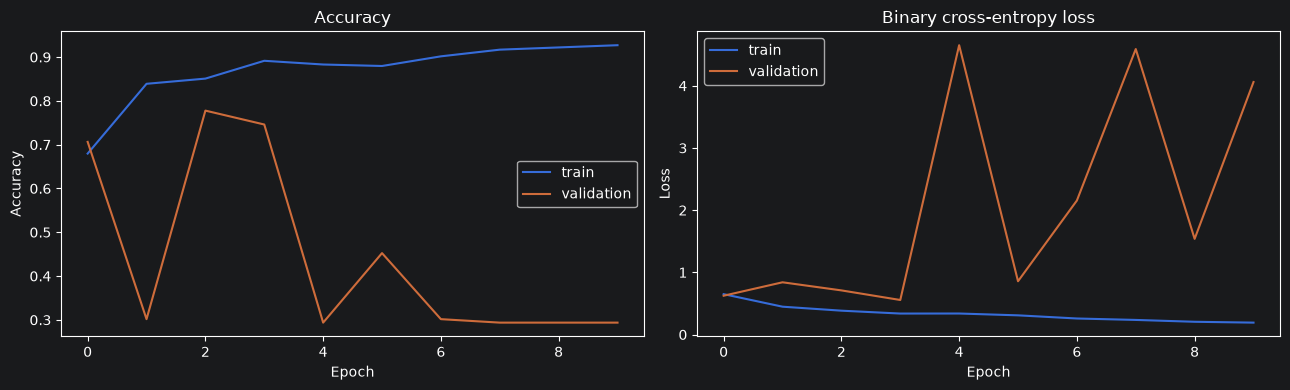

In [13]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_df["accuracy"], label="train")
axes[0].plot(history_df["val_accuracy"], label="validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history_df["loss"], label="train")
axes[1].plot(history_df["val_loss"], label="validation")
axes[1].set_title("Binary cross-entropy loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


## 11. Final evaluation on the untouched test set

The test set is used only after training and model selection are complete. Precision measures how often predicted passport pages are correct; recall measures how many real passport pages were found; F1 balances both.


In [14]:
best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

test_metrics = best_model.evaluate(test_ds, return_dict=True, verbose=0)
display(pd.Series(test_metrics, name="test_value").to_frame())

y_true = test_df["label"].to_numpy()
y_probability = best_model.predict(test_ds, verbose=0).reshape(-1)
y_predicted = (y_probability >= DECISION_THRESHOLD).astype(int)

report = pd.DataFrame(
    classification_report(
        y_true,
        y_predicted,
        target_names=[LABEL_NAMES[0], LABEL_NAMES[1]],
        digits=4,
        output_dict=True,
        zero_division=0,
    )
).transpose()

display(report)


,test_value
accuracy,0.723577
loss,0.618484
precision,0.500000
recall,0.352941
roc_auc,0.814111


,precision,recall,f1-score,support
No passport,0.777778,0.865169,0.819149,89.000000
Passport,0.500000,0.352941,0.413793,34.000000
accuracy,0.723577,0.723577,0.723577,0.723577
macro avg,0.638889,0.609055,0.616471,123.000000
weighted avg,0.700994,0.723577,0.707099,123.000000


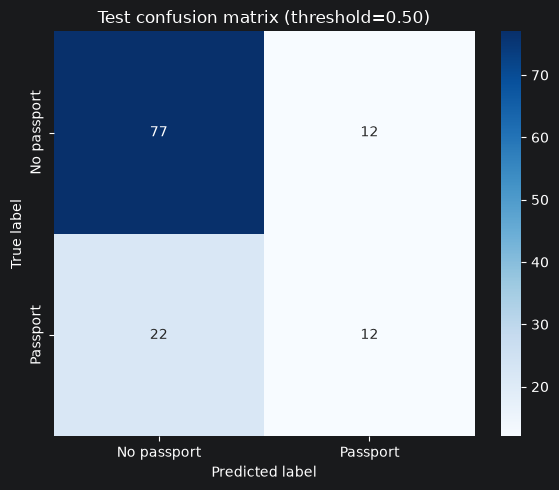

In [15]:
matrix = confusion_matrix(y_true, y_predicted, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]],
    yticklabels=[LABEL_NAMES[0], LABEL_NAMES[1]],
)
plt.title(f"Test confusion matrix (threshold={DECISION_THRESHOLD:.2f})")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


## 12. Inspect predictions

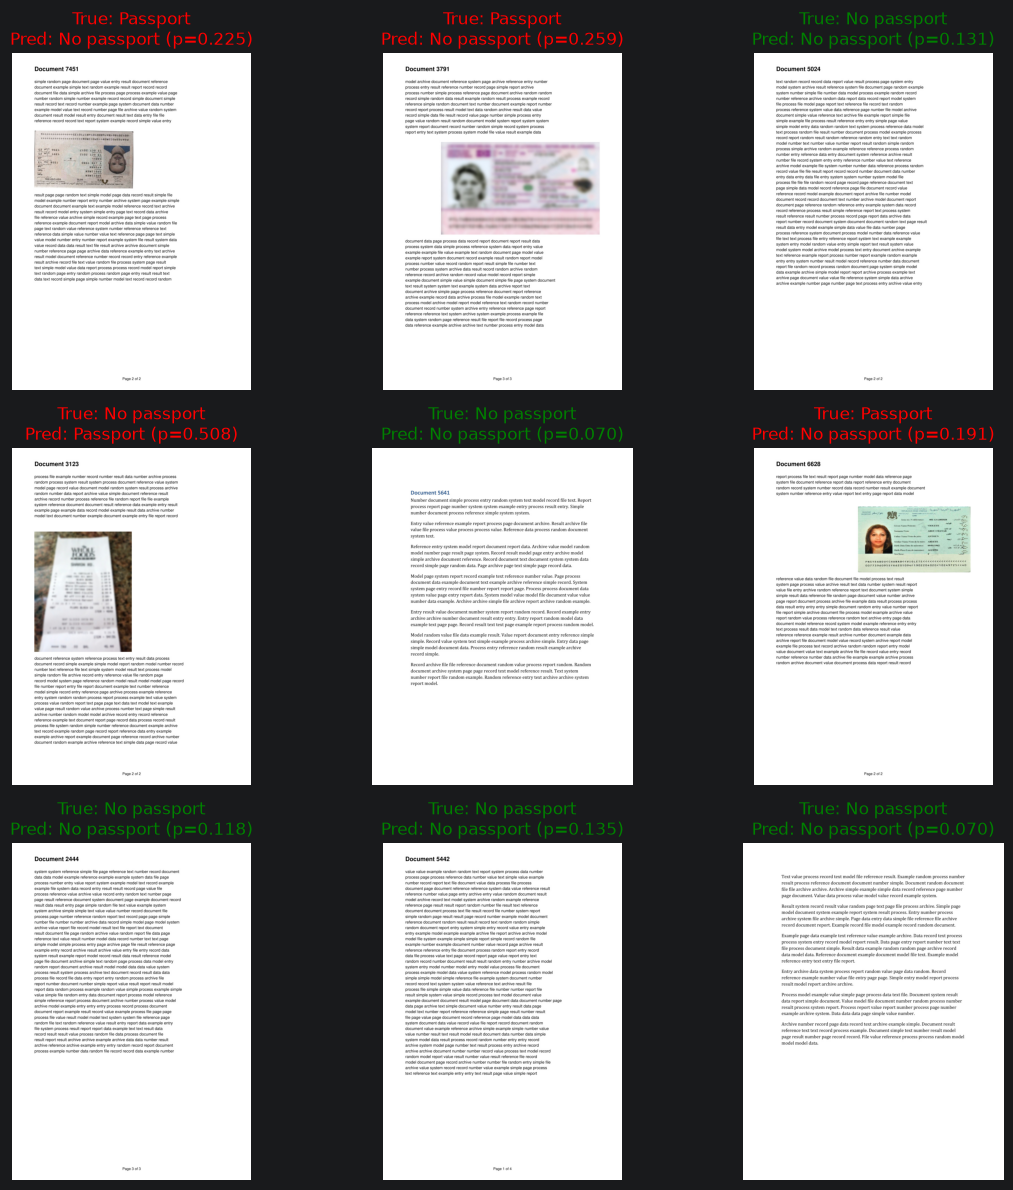

In [16]:
prediction_df = test_df[["image_path", "resolved_path", "label"]].copy()
prediction_df["passport_probability"] = y_probability
prediction_df["predicted_label"] = y_predicted

examples = prediction_df.sample(min(9, len(prediction_df)), random_state=SEED)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = np.asarray(axes).reshape(-1)

for ax in axes:
    ax.axis("off")

for ax, (_, row) in zip(axes, examples.iterrows()):
    with Image.open(row["resolved_path"]) as image:
        ax.imshow(image.convert("RGB"))

    true_name = LABEL_NAMES[int(row["label"])]
    predicted_name = LABEL_NAMES[int(row["predicted_label"])]
    color = "green" if row["label"] == row["predicted_label"] else "red"

    ax.set_title(
        f"True: {true_name}\nPred: {predicted_name} "
        f"(p={row['passport_probability']:.3f})",
        color=color,
    )
    ax.axis("off")

plt.tight_layout()
plt.show()


## 13. Predict one new page

In [17]:
def predict_passport_page(image_path, threshold=DECISION_THRESHOLD):
    image = tf.keras.utils.load_img(
        image_path,
        target_size=(IMG_SIZE, IMG_SIZE),
        color_mode="rgb",
    )
    image_array = tf.keras.utils.img_to_array(image)
    probability = float(best_model.predict(image_array[None, ...], verbose=0)[0, 0])

    return {
        "image_path": str(image_path),
        "passport_probability": probability,
        "predicted_label": int(probability >= threshold),
        "predicted_class": LABEL_NAMES[int(probability >= threshold)],
    }


# Example:
# predict_passport_page("data/pages/new_page.jpg")


## Interpretation notes

- Prefer the passport-class **recall and F1** over accuracy alone because the classes are imbalanced.
- A large gap between training and validation curves indicates overfitting.
- Very high performance should be checked carefully for duplicate pages, synthetic artifacts, or document leakage.
- For a production comparison, keep this CNN as the baseline and test transfer learning (for example, EfficientNetB0) with the exact same document-level split.


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score

y_validation = validation_df["label"].to_numpy()
validation_probability = best_model.predict(
    validation_ds, verbose=0
).reshape(-1)

threshold_results = []

for threshold in np.arange(0.05, 0.96, 0.01):
    predictions = (validation_probability >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_validation, predictions, zero_division=0
        ),
        "recall": recall_score(
            y_validation, predictions, zero_division=0
        ),
        "f1": f1_score(
            y_validation, predictions, zero_division=0
        ),
        "f2": fbeta_score(
            y_validation, predictions, beta=2, zero_division=0
        ),
    })

threshold_results = pd.DataFrame(threshold_results)

best_result = threshold_results.loc[
    threshold_results["f2"].idxmax()
]

display(best_result)

DECISION_THRESHOLD = float(best_result["threshold"])

threshold    0.140000
precision    0.704545
recall       0.837838
f1           0.765432
f2           0.807292
Name: 9, dtype: float64

In [19]:
y_probability = best_model.predict(test_ds, verbose=0).reshape(-1)
y_predicted = (y_probability >= DECISION_THRESHOLD).astype(int)

print(
    classification_report(
        y_true,
        y_predicted,
        target_names=["No passport", "Passport"],
        digits=4,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

 No passport     0.9494    0.8427    0.8929        89
    Passport     0.6818    0.8824    0.7692        34

    accuracy                         0.8537       123
   macro avg     0.8156    0.8625    0.8310       123
weighted avg     0.8754    0.8537    0.8587       123

